# Assignment 1 Part 1

## Part 1a
- Random number in range [0,1]                       : Discrete
- Number of bike stores in Groningen                 : Discrete
- Handedness                                         : Categorical
- Current types of Machine Learning methods.         : Categorical
- Duration of your trip from home to campus Zernike. : Continuous

## Part 1b
Features:
1. Number of coffee units drunk per day.
2. Number of study hours.
3. Number of sleeping hours.
4. Country where a student obtained their high school diploma.
5. Age.
6. Number of times the student attended lectures.

Answer these two questions, considering the problem of individual student success rate.
1. Which of these features is/are useful to predict the success rate of students passing a course?
Please explain your choice.
    - 2, 3, 4, 6
    - 2: If the student studies more, they tend to do better
    - 3: Need sleep to function
    - 4: Dictates base knowledge, might need to study more to compensate
    - 6: Shows commitment to the course and discipline to study

2. Is predicting the success rate of students passing a course a classification or a regression task?
Please explain your reasoning.
    - Regression.
    - This is more of a prediction task, where we are forecasting the chance a student will do well in the course. 

## Part 1c

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

# as_frame=True returns the 8 features and the target already joined in one DataFrame.
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [5]:
# Choosing features and target variable
features_housing = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']
x_all = df.drop(columns=['MedHouseVal'])
x_housing = df[features_housing]
y_housing = df['MedHouseVal']

In [6]:
# Linear regression with selected features

x_train, x_test, y_train, y_test = train_test_split(x_housing, y_housing, test_size = 0.2, random_state = 42)

# Normalize the features using minmax scaling
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) 

model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)

print("selected features, R2 =", r2_score(y_test, predictions))
for name, coef in zip(features_housing, model.coef_):
    print(name, round(coef, 3))

selected features, R2 = 0.5089947802907755
MedInc 7.902
HouseAge 0.847
AveRooms -31.45
AveBedrms 28.098
Population 0.684


Explanation:
- The selected features produced a R2 score of 0.509 (3sf).
- This suggests that the selected features contain useful information for predicting house prices, although a substantial amount of variation remains unexplained.
- Therefore, the R2 score is not sufficient to determine whether the relationship between the features and target is truly linear. 

In [7]:
# Linear regression with all features

x_train2, x_test2, y_train2, y_test2 = train_test_split(x_all, y_housing, test_size = 0.2, random_state = 42)

model_all = LinearRegression()
model_all.fit(x_train2, y_train2)
predictions_all = model_all.predict(x_test2)

print("all features, R2 =", r2_score(y_test2, predictions_all))

all features, R2 = 0.5757877060324514


Comparison of R2 of selected features and all features:
- The model using all features achieved a R2 score of 0.576 (3sf), compared with 0.509 for the selected features.
- The higher R2 score indicates that the additional features provided useful predictive information that was not captured by the selected features alone.

In [8]:
# Single transformation of selected features

x_new = x_housing.copy()
x_new['MedInc'] = np.log(x_new['MedInc'])
x_new['HouseAge'] = np.sqrt(x_new['HouseAge'])
x_new['AveRooms'] = np.log(x_new['AveRooms'])
x_new['AveBedrms'] = np.log(x_new['AveBedrms'])
x_new['Population'] = np.log(x_new['Population'])

In [9]:
# Linear regression with transformed features

x_train3, x_test3, y_train3, y_test3 = train_test_split(x_new, y_housing, test_size = 0.2, random_state = 42)

model_new = LinearRegression()
model_new.fit(x_train3, y_train3)
predictions_new = model_new.predict(x_test3)

print("transformed features, R2 =", r2_score(y_test3, predictions_new))

transformed features, R2 = 0.48625396966876977


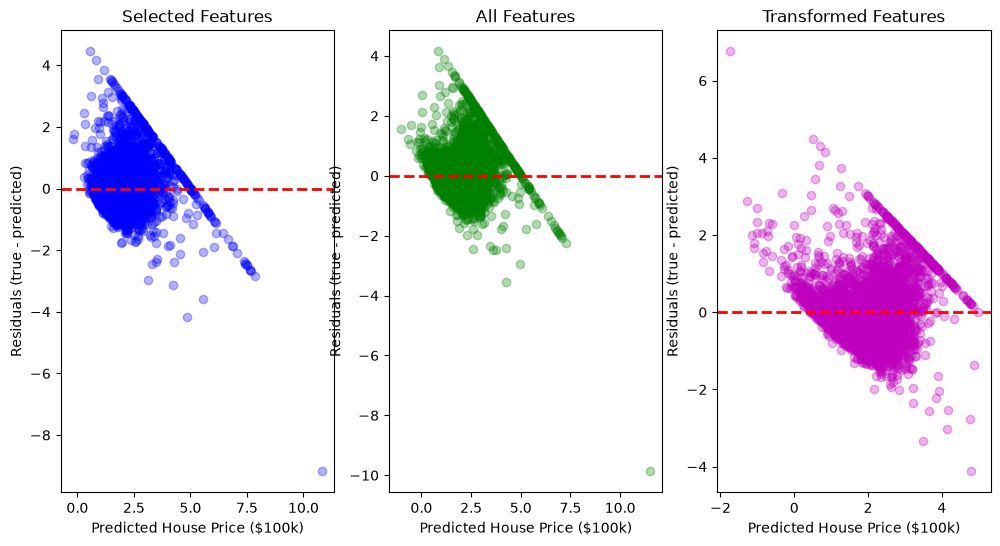

In [10]:
# Residual plots

residuals = y_test - predictions
residuals_all = y_test2 - predictions_all
residuals_new = y_test3 - predictions_new

plots = [(predictions, residuals, 'b', "Selected Features"),
         (predictions_all, residuals_all, 'g', "All Features"),
         (predictions_new, residuals_new, 'm', "Transformed Features")]

plt.figure(figsize = (12,6))
for i, (pred, res, color, title) in enumerate(plots, start = 1):
    plt.subplot(1, 3, i)
    plt.scatter(pred, res, color = color, alpha = 0.3)
    plt.axhline(y = 0, color = 'r', linestyle = '--', linewidth = 2)
    plt.xlabel('Predicted House Price ($100k)')
    plt.ylabel('Residuals (true - predicted)')
    plt.title(title)

Evaluation:
- The three residual plots show a similar pattern: rather than scattering randomly around the y = 0 line, the residuals form a downward-sloping trend in all three cases (selected, all, and transformed features).
- This indicates that even after transformation, the model is over-predicting at higher predicted prices and under-predicting at lower ones. 
- The transformed features achieved a R2 score of 0.486 (3sf), which is lower than the untransformed selected features model's R2 score of 0.509 (3sf), suggesting that this particular transformation did not improve the linear fit.
- Perhaps a different transformation or feature may better linearize the relationship.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame

print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [12]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [13]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

In [14]:
#Choose Features

selected_features = [
    "alcohol",
    "flavanoids",
    "total_phenols",
    "color_intensity",
    "proline",
    "od280/od315_of_diluted_wines"
]

X = df[selected_features]

y = df["target"]

In [15]:
#Split train/test data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
#Train Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [23]:
#Evaluate accuracy

accuracy = model.score(X_test, y_test)

train_accuracy = model.score(X_train, y_train)

print("train", train_accuracy)
print("Accuracy:", accuracy)

train 0.9788732394366197
Accuracy: 1.0


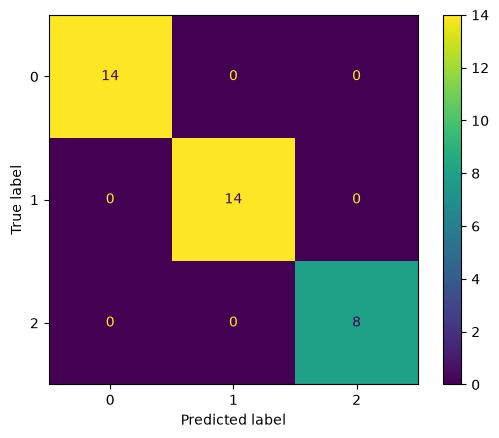

In [18]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [19]:
#Compare with all features

X_all = df.drop("target", axis=1)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42
)

model_all = LogisticRegression(max_iter=10000)

model_all.fit(X_train_all, y_train_all)

accuracy_all = model_all.score(
    X_test_all,
    y_test_all
)

print("Accuracy using all features:", accuracy_all)

Accuracy using all features: 1.0


In [20]:
print("Training accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Training accuracy: 0.9788732394366197
Test accuracy: 1.0


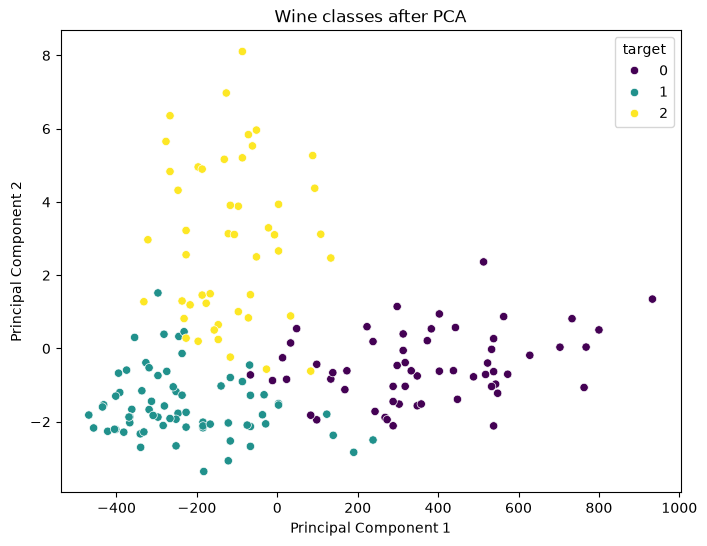

In [21]:
#Check linear separability

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Wine classes after PCA")

plt.show()

Accuracy after transformation: 1.0


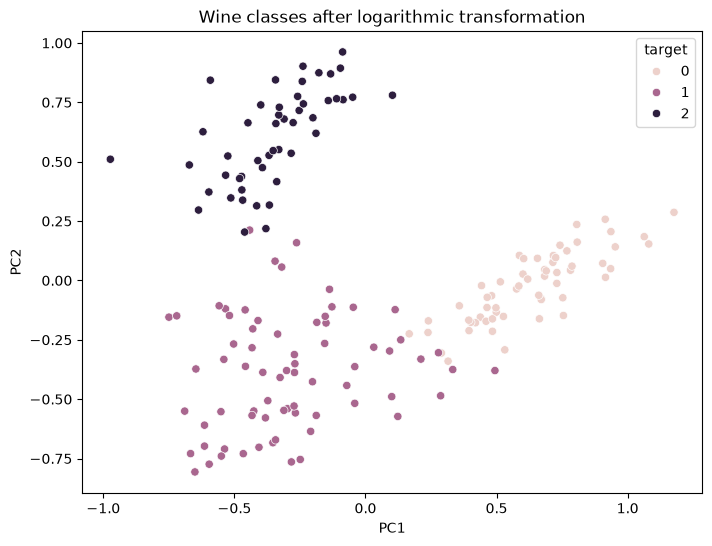

In [22]:
#Transformation

X_transformed = np.log1p(X)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_transformed,
    y,
    test_size=0.2,
    random_state=42
)

model_t = LogisticRegression(max_iter=10000)

model_t.fit(X_train_t,y_train_t)

accuracy_t = model_t.score(
    X_test_t,
    y_test_t
)

print("Accuracy after transformation:", accuracy_t)

pca = PCA(n_components=2)

X_pca_t = pca.fit_transform(X_transformed)


plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca_t[:,0],
    y=X_pca_t[:,1],
    hue=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Wine classes after logarithmic transformation")

plt.show()

Answer
 
- The six selected features were used to train a logistic regression model. The model achieved 97.89% training accuracy and 100% test accuracy. The confusion matrix also shows that all 36 test samples were classified correctly. Since logistic regression is a linear model, these results suggest that the selected features are fairly well linearly separable. The PCA plot also shows that the three wine classes form mostly separate groups, although there is some overlap between classes 1 and 2.
- Then applied a logarithmic transformation was applied to the selected features. The transformed model also achieved 100% test accuracy, so the transformation did not improve the classification accuracy. The PCA plot after transformation still shows relatively clear separation between the three classes. Overall, the transformation did not make a major difference because the original features were already performing very well.